# **Spam Email Detection Using Naive Bayes Classification**
<center>
<table width='40%'>
<tr>
<th> Name </th>
<td>:</td>
<td> Sadman Ishtiak </td>
</tr><tr>
<th> Roll </th>
<td>:</td>
<td> 22102009 </td>
</tr><tr>
<th> Reg </th>
<td>:</td>
<td> 10815 </td>
</tr><tr>
<th> Session </th>
<td>:</td>
<td> 2021-22 </td>
</tr>
</table>
</center>

## Folder Cleanup and Preparation
First we delete the thngs that we have in the memory currently. The program is tested and written on debian based linux.

In [1]:
!rm *.csv.*
!rm *.csv

rm: cannot remove '*.csv.*': No such file or directory
rm: cannot remove '*.csv': No such file or directory


## Data Collection
Then we downdload the data that is stored in the internet publicly.

In [2]:
!wget https://raw.githubusercontent.com/Sadman-Ishtiak/spam-email-detection-using-using-naive-bayes-classification/refs/heads/main/emails.csv

--2026-04-28 19:24:14--  https://raw.githubusercontent.com/Sadman-Ishtiak/spam-email-detection-using-using-naive-bayes-classification/refs/heads/main/emails.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8954755 (8.5M) [text/plain]
Saving to: ‘emails.csv’

emails.csv          100%[===================>]   8.54M  --.-KB/s    in 0.1s    

2026-04-28 19:24:15 (87.4 MB/s) - ‘emails.csv’ saved [8954755/8954755]



Check the data downloaded successfully

In [3]:
!ls

emails.csv  sample_data


## Dataframe Creation
Then we import pandas and then, convert the csv file into a pandas dataframe into the memory.

In [4]:
import pandas as pd
df = pd.read_csv('emails.csv')
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


## Data Balance Check (EDA)
Then we check the balance of the data ie if the numbers of spam and not spam in the dataframe.

In [5]:
# print(df.info())
print(f"Number of Spams : {sum(df['spam'] == 1)}")
print(f"Non Spam Number : {sum(df['spam'] == 0)}")

1368 + 4360 # = 5728 for check

Number of Spams : 1368
Non Spam Number : 4360


5728

## Preprocessing the data
We have seen the balance of the data is not proper, but lets process the data by spliting the `text` column into words, wordcount, lowercase, uppercase, symbols, spaces, tabs and line breaks.

In [6]:
import string

data = []
for i in range(len(df)):
  row = {}
  row['text'] = df['text'][i]
  row['spam'] = df['spam'][i]
  row['len'] = len(row['text'])
  row['words'] = row['text'].split()
  row['wc'] = len(row['text'].split())
  row['num_digits'] = sum(c.isdigit() for c in row['text'])
  row['num_upper'] = sum(c.isupper() for c in row['text'])
  row['num_lower'] = sum(c.islower() for c in row['text'])
  row['num_punct'] = sum(c in string.punctuation for c in row['text'])
  row['num_spaces'] = sum(c == ' ' for c in row['text'])
  row['num_tabs'] = sum(c == '\t' for c in row['text'])
  row['num_newlines'] = sum(c == '\n' for c in row['text'])
  data.append(row)
df = pd.DataFrame(data)
df.describe()

,spam,len,wc,num_digits,num_upper,num_lower,num_punct,num_spaces,num_tabs,num_newlines
count,5728.000000,5728.000000,5728.000000,5728.000000,5728.0,5728.000000,5728.000000,5728.000000,5728.0,5728.0
mean,0.238827,1556.768680,326.848638,37.366446,1.0,1077.015712,84.289979,356.919867,0.0,0.0
std,0.426404,2042.649812,418.777435,75.282776,0.0,1478.933905,123.440851,451.190249,0.0,0.0
min,0.000000,13.000000,2.000000,0.000000,1.0,9.000000,1.000000,2.000000,0.0,0.0
25%,0.000000,508.750000,101.000000,5.000000,1.0,355.000000,18.000000,112.000000,0.0,0.0
50%,0.000000,979.000000,210.000000,22.000000,1.0,667.000000,46.000000,231.000000,0.0,0.0
75%,0.000000,1894.250000,401.000000,48.000000,1.0,1275.250000,113.000000,438.000000,0.0,0.0
max,1.000000,43952.000000,8477.000000,4149.000000,1.0,33473.000000,2050.000000,8983.000000,0.0,0.0


### Cleanup zero data
the `num_upper`, `num_tabs` and `num_newlines` dont have any values ie 0. so we can simply delete them.

In [7]:
df.drop(['num_upper', 'num_tabs', 'num_newlines'], axis=1, inplace=True)

## Regression check
Then we check regression for the nummeric values with the spam if this is actually works with and we can use a regression or not.

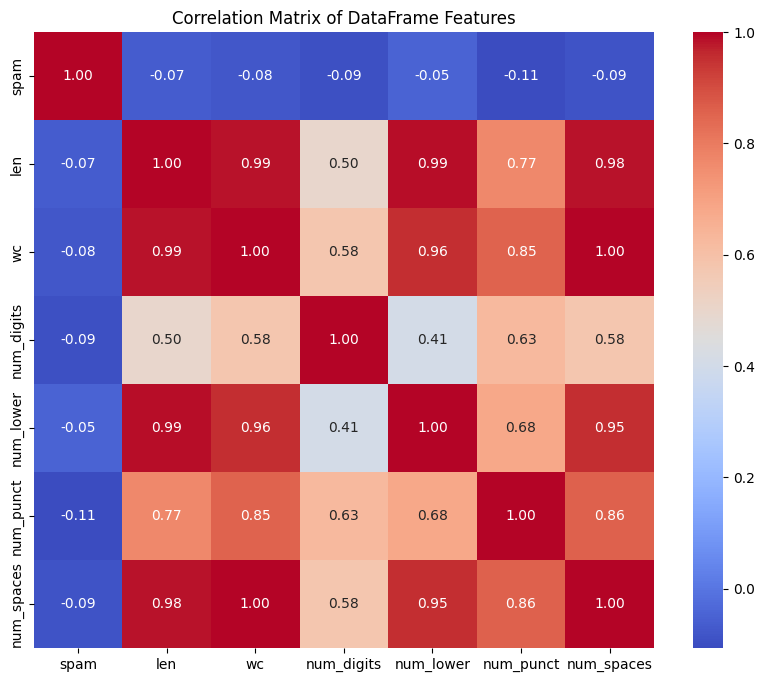

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of DataFrame Features')
plt.show()

Which turns out to be a huge fail. as there are no linear relation between spam and any other numeric columns in the dataframe. so we can drop them.

In [9]:
df.drop(['num_digits', 'num_lower', 'num_punct', 'num_spaces'], axis=1, inplace=True)
df

,text,spam,len,words,wc
0,Subject: naturally irresistible your corporate...,1,1484,"[Subject:, naturally, irresistible, your, corp...",324
1,Subject: the stock trading gunslinger fanny i...,1,598,"[Subject:, the, stock, trading, gunslinger, fa...",89
2,Subject: unbelievable new homes made easy im ...,1,448,"[Subject:, unbelievable, new, homes, made, eas...",87
3,Subject: 4 color printing special request add...,1,500,"[Subject:, 4, color, printing, special, reques...",98
4,"Subject: do not have money , get software cds ...",1,235,"[Subject:, do, not, have, money, ,, get, softw...",52
...,...,...,...,...,...
5723,Subject: re : research and development charges...,0,1189,"[Subject:, re, :, research, and, development, ...",297
5724,"Subject: re : receipts from visit jim , than...",0,1167,"[Subject:, re, :, receipts, from, visit, jim, ...",244
5725,Subject: re : enron case study update wow ! a...,0,2131,"[Subject:, re, :, enron, case, study, update, ...",515
5726,"Subject: re : interest david , please , call...",0,1060,"[Subject:, re, :, interest, david, ,, please, ...",276


## Word Preprocessor
Since we have found that we cannot use a regression method so the next general advice is to use the words and their relations between the word by getting rid of the same word in different format. (works, work, working, worked ---> work)

In [10]:
# Copied from the internet

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK datasets (run these once)
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_spam(text):
    # 2. Clean: Remove non-letters & lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()

    # 3. Tokenize: Split into words
    words = text.split()

    # 4. Lemmatize & Remove Stopwords
    # Converts 'winning' -> 'win', 'prizes' -> 'prize'
    clean_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(clean_words)

# Example output:
# "Congratulations! You are winning a free prize!"
# -> "congratulation win free prize"

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## Converting the df with the observations that we have had from the previous explorations

In [11]:
import string

data = []
for i in range(len(df)):
  row = {}
  row['text'] = preprocess_spam(df['text'][i])
  row['spam'] = df['spam'][i]
  row['len'] = len(row['text'])
  row['words'] = row['text'].split()
  row['wc'] = len(row['text'].split())
  # row['num_digits'] = sum(c.isdigit() for c in row['text'])
  # row['num_upper'] = sum(c.isupper() for c in row['text'])
  row['num_lower'] = sum(c.islower() for c in row['text'])
  # row['num_punct'] = sum(c in string.punctuation for c in row['text'])
  row['num_spaces'] = sum(c == ' ' for c in row['text'])
  # row['num_tabs'] = sum(c == '\t' for c in row['text'])
  # row['num_newlines'] = sum(c == '\n' for c in row['text'])
  row['words'] = row['text'].split()
  data.append(row)
df = pd.DataFrame(data)
df

,text,spam,len,words,wc,num_lower,num_spaces
0,subject naturally irresistible corporate ident...,1,888,"[subject, naturally, irresistible, corporate, ...",113,776,112
1,subject stock trading gunslinger fanny merrill...,1,505,"[subject, stock, trading, gunslinger, fanny, m...",64,442,63
2,subject unbelievable new home made easy im wan...,1,276,"[subject, unbelievable, new, home, made, easy,...",40,237,39
3,subject color printing special request additio...,1,333,"[subject, color, printing, special, request, a...",46,288,45
4,subject money get software cd software compati...,1,128,"[subject, money, get, software, cd, software, ...",19,110,18
...,...,...,...,...,...,...,...
5723,subject research development charge gpg forwar...,0,656,"[subject, research, development, charge, gpg, ...",106,551,105
5724,subject receipt visit jim thanks invitation vi...,0,769,"[subject, receipt, visit, jim, thanks, invitat...",119,651,118
5725,subject enron case study update wow day super ...,0,1165,"[subject, enron, case, study, update, wow, day...",188,978,187
5726,subject interest david please call shirley cre...,0,570,"[subject, interest, david, please, call, shirl...",97,474,96


### Seeing the data description

In [12]:
df.describe()

,spam,len,wc,num_lower,num_spaces
count,5728.000000,5728.000000,5728.000000,5728.000000,5728.000000
mean,0.238827,959.874476,138.347591,822.526885,137.347591
std,0.426404,1303.785945,181.122094,1123.428139,181.122094
min,0.000000,11.000000,2.000000,10.000000,1.000000
25%,0.000000,324.000000,48.000000,277.000000,47.000000
50%,0.000000,599.000000,88.000000,512.000000,87.000000
75%,0.000000,1135.000000,166.000000,971.000000,165.000000
max,1.000000,29345.000000,4110.000000,25236.000000,4109.000000


## Words and Unique words separation

In [13]:
all_words = []

for i in df['words']:
  # print(i)
  for j in i:
    all_words.append(j)
print(len(all_words))
unique_words = set(all_words)
print(len(unique_words))

792455
30986


## Vectorization of the message text
Since all data science needs to be worked with numerical data we now convert the text of the message into an array of numbers. All the characters are put in a counter with lexicographical order of the unique words.

In [14]:
word_to_index = {word: i for i, word in enumerate(sorted(list(unique_words)))}

def custom_vectorize(text_words, vocabulary_map):
    vector = [0] * len(vocabulary_map)
    word_counts = {}

    for word in text_words:
        word_counts[word] = word_counts.get(word, 0) + 1
    for word, count in word_counts.items():
        if word in vocabulary_map:
            vector[vocabulary_map[word]] = count
    return vector


vectorized_data = []
for x in df['words']:
    vectorized_data.append(custom_vectorize(x, word_to_index))
df['vector'] = vectorized_data


df

,text,spam,len,words,wc,num_lower,num_spaces,vector
0,subject naturally irresistible corporate ident...,1,888,"[subject, naturally, irresistible, corporate, ...",113,776,112,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,subject stock trading gunslinger fanny merrill...,1,505,"[subject, stock, trading, gunslinger, fanny, m...",64,442,63,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,subject unbelievable new home made easy im wan...,1,276,"[subject, unbelievable, new, home, made, easy,...",40,237,39,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,subject color printing special request additio...,1,333,"[subject, color, printing, special, request, a...",46,288,45,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,subject money get software cd software compati...,1,128,"[subject, money, get, software, cd, software, ...",19,110,18,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...
5723,subject research development charge gpg forwar...,0,656,"[subject, research, development, charge, gpg, ...",106,551,105,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5724,subject receipt visit jim thanks invitation vi...,0,769,"[subject, receipt, visit, jim, thanks, invitat...",119,651,118,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5725,subject enron case study update wow day super ...,0,1165,"[subject, enron, case, study, update, wow, day...",188,978,187,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5726,subject interest david please call shirley cre...,0,570,"[subject, interest, david, please, call, shirl...",97,474,96,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## Standard Naive Bayes models
Among the 5 available Naive Bayes models in the scikit learn library we can use the Gaussian, Multinomial, Bernoulli and Complement in this case. So, lets split the data into X, Y axis and convert them into numpy array to see what kinds of accuracy we can get.

In [15]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, classification_report

# Fix: Convert the column of lists into a 2D numpy array
X = np.array(df['vector'].tolist())
Y = df['spam']

# train test split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2441139)

print("Gaussian Naive Bayes")
gnb = GaussianNB()
gnb.fit(x_train, y_train)
# print(gnb.get_params())
pred_gnb = gnb.predict(x_test)
print(accuracy_score(y_test, pred_gnb))
print(classification_report(y_test, pred_gnb))

print("Multinomial Naive Bayes")
mnb = MultinomialNB()
mnb.fit(x_train, y_train)
# print(mnb.get_params())
pred_mnb = mnb.predict(x_test)
print(accuracy_score(y_test, pred_mnb))
print(classification_report(y_test, pred_mnb))

print("Bernoulli Naive Bayes")
bnb = BernoulliNB()
bnb.fit(x_train, y_train)
# print(bnb.get_params())
pred_bnb = bnb.predict(x_test)
print(accuracy_score(y_test, pred_bnb))
print(classification_report(y_test, pred_bnb))

print("Complement Naive Bayes")
cnb = ComplementNB()
cnb.fit(x_train, y_train)
# print(cnb.get_params())
pred_cnb = cnb.predict(x_test)
print(accuracy_score(y_test, pred_cnb))
print(classification_report(y_test, pred_cnb))

Gaussian Naive Bayes
0.962478184991274
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       890
           1       0.95      0.88      0.91       256

    accuracy                           0.96      1146
   macro avg       0.96      0.93      0.94      1146
weighted avg       0.96      0.96      0.96      1146

Multinomial Naive Bayes
0.9895287958115183
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       890
           1       0.96      0.99      0.98       256

    accuracy                           0.99      1146
   macro avg       0.98      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146

Bernoulli Naive Bayes
0.9773123909249564
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       890
           1       0.96      0.94      0.95       256

    accuracy                           0.98      1146
   ma

## Bagging with the four Models
Although the four model bagging or voting model is not good If it can make a more accurate model it would be better to make and use that. over a single model

In [16]:
def bagging(models, x_test, y_test):
  predictions = []
  for model in models:
    pred = model.predict(x_test)
    predictions.append(pred)
  answer = []
  for i in range(len(y_test)):
    temp = []
    for j in range(len(models)):
      temp.append(predictions[j][i])
    answer.append(max(set(temp), key=temp.count))
  return np.array(answer)

### Testing Precision with the Ensambled voting

In [17]:
bagged_pred = bagging([gnb, mnb, bnb, cnb], x_test, y_test)
print(accuracy_score(y_test, bagged_pred))
print(classification_report(y_test, bagged_pred))

0.9904013961605584
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       890
           1       0.98      0.98      0.98       256

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



## Inverting the data with 80% test and 20% learn data

In [18]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.8, random_state=2441139)
gnbi = GaussianNB()
gnbi.fit(x_train, y_train)
mnbi = MultinomialNB()
mnbi.fit(x_train, y_train)
bnbi = BernoulliNB()
bnbi.fit(x_train, y_train)
cnbi = ComplementNB()
cnbi.fit(x_train, y_train)
bagged_pred = bagging([gnbi, mnbi, bnbi, cnbi], x_test, y_test)
print(accuracy_score(y_test, bagged_pred))
print(classification_report(y_test, bagged_pred))

0.9522147065241109
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      3496
           1       0.99      0.81      0.89      1087

    accuracy                           0.95      4583
   macro avg       0.97      0.90      0.93      4583
weighted avg       0.95      0.95      0.95      4583

